In [1]:
# download data if it isn't already present
import os
import gdown
import zstandard as zstd
import tarfile

DATA_FOLDER = "data_v2"
DATA_URL = "https://drive.google.com/file/d/19vWC9-Y6_KXTf0ONPIaJ7SSTUlaM24u7/view?usp=sharing"

if not os.path.exists(DATA_FOLDER):
    tar_path = DATA_FOLDER + ".tar"
    gdown.download(url=DATA_URL, output=tar_path)
    os.makedirs(DATA_FOLDER)
    with tarfile.open(DATA_FOLDER+".tar", 'r') as tar:
        tar.extractall(path=DATA_FOLDER)

    decompressor = zstd.ZstdDecompressor()

    for root, dirs, files in os.walk(DATA_FOLDER):
        for file in files:
            input_path = os.path.join(root, file)
            output_file_name = file.replace('.zst', '')
            output_path = os.path.join(DATA_FOLDER, output_file_name)
            
            with open(input_path, 'rb') as ifh, open(output_path, 'wb') as ofh:
                decompressor.copy_stream(ifh, ofh)
            os.remove(input_path)
            

### calendar.csv
Contains the following columns, which we assume follow the Airbnb Open Data format:
- listing_id (20% missing) - id of listing
- date (20% missing) - date that info refers to
- available (20% missing) - is the listing available at said date
- price (100% missing) - nightly rate
- adjusted_price (100% missing) - nightly rate after discounts
- minimum_nights (20% missing) - minimum reservation length at date
- maximum_nights (20% missing) - maximum reservation at date

*Information about missing data percentages was gathered using the Data Wrangler plugin.*

In [2]:
import pandas as pd
from pathlib import Path

calendar_df = pd.read_csv(Path(DATA_FOLDER) / "calendar.csv")
calendar_df.head(n=10)

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,5.967576e+17,2026-08-10,f,NaN,NaN,15.0,100.0
1,8.018929e+17,2026-09-23,t,NaN,NaN,100.0,1125.0
2,1.310237e+18,2026-08-09,t,NaN,NaN,1.0,365.0
3,1.072459e+18,2026-04-14,NaN,NaN,NaN,100.0,500.0
4,NaN,2026-07-19,t,NaN,NaN,100.0,365.0
5,8.331230e+17,2025-11-21,t,NaN,NaN,NaN,90.0
6,9.789746e+17,2026-02-04,t,NaN,NaN,100.0,NaN
7,7.424888e+17,2026-01-18,f,NaN,NaN,3.0,729.0
8,NaN,2026-07-07,f,NaN,NaN,NaN,90.0
9,4.639045e+07,2026-05-15,t,NaN,NaN,100.0,NaN


In [3]:
pd.Series(calendar_df["listing_id"].value_counts()).describe()

count    30051.000000
mean       204.410935
std          9.540610
min        168.000000
25%        198.000000
50%        204.000000
75%        211.000000
max        241.000000
Name: count, dtype: float64

Seems like the number of rows per listing is quite similar and hovers around 200.

In [ ]:
print(f"Total rows: {len(calendar_df)}")
nan_rows_count = calendar_df.drop(columns=["price", "adjusted_price"]).isna().any(axis=1).sum()
print(f"Rows with any missing values: {nan_rows_count}")

Total rows: 7677994
Rows with any missing values: 5162659


In [ ]:
# check out the "date" column
calendar_df["date"] = pd.to_datetime(calendar_df["date"])
calendar_df["date"].describe()

count                       6142459
mean     2026-03-31 08:15:44.360295
min             2025-09-30 00:00:00
25%             2025-12-30 00:00:00
50%             2026-03-31 00:00:00
75%             2026-07-01 00:00:00
max             2026-09-30 00:00:00
Name: date, dtype: object

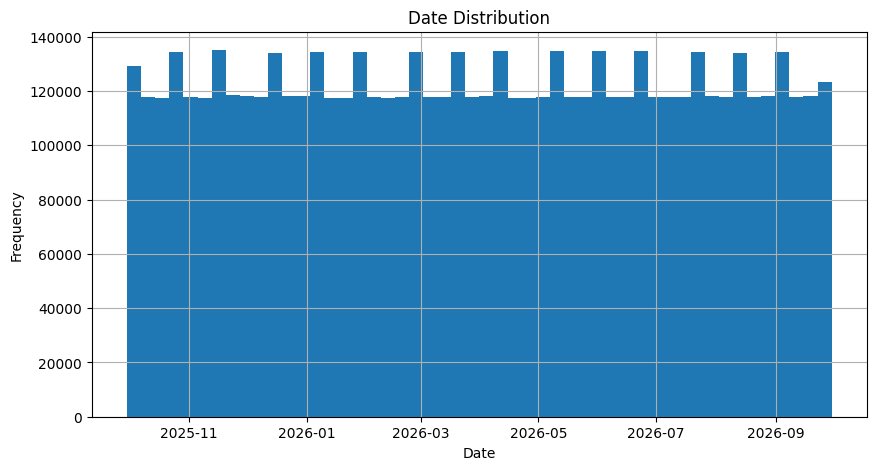

In [ ]:
import matplotlib.pyplot as plt

calendar_df['date'].hist(bins=50, figsize=(10, 5))
plt.title('Date Distribution')
plt.xlabel('Date')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# check if dates are unique for listings
assert(max(calendar_df[["date", "listing_id"]].value_counts()) == 1)
# dates are unique for listings!

In [ ]:
calendar_df["available"].value_counts()

available
t    4758498
f    1385039
Name: count, dtype: int64

In [ ]:
# availability ratio could be used as an attribute to judge how attractive a location is
calendar_df["available_bool"] = calendar_df["available"] == "t"

# assume that missing data in available column is MCAR - this will need to be checked
# is ratios are used as an attribute
availability_ratios = calendar_df.groupby('listing_id', dropna=True)['available_bool'].mean()

availability_df = availability_ratios.reset_index()
availability_df.columns = ['listing_id', 'availability_ratio']

print(availability_df.head())

   listing_id  availability_ratio
0     25436.0            0.000000
1     34177.0            0.758140
2     42835.0            0.162162
3     73477.0            0.790476
4     77292.0            0.814070


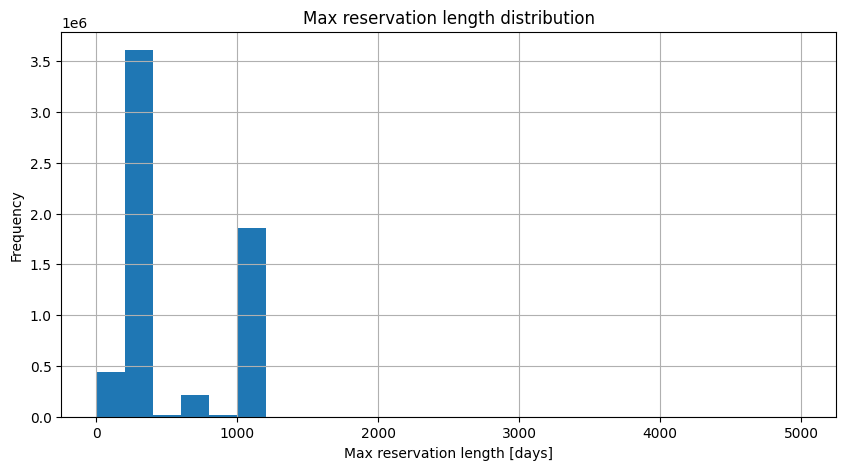

In [ ]:
import matplotlib.pyplot as plt

calendar_df['maximum_nights'].hist(bins=25, figsize=(10, 5))
plt.title('Max reservation length distribution')
plt.xlabel('Max reservation length [days]')
plt.ylabel('Frequency')
plt.show()


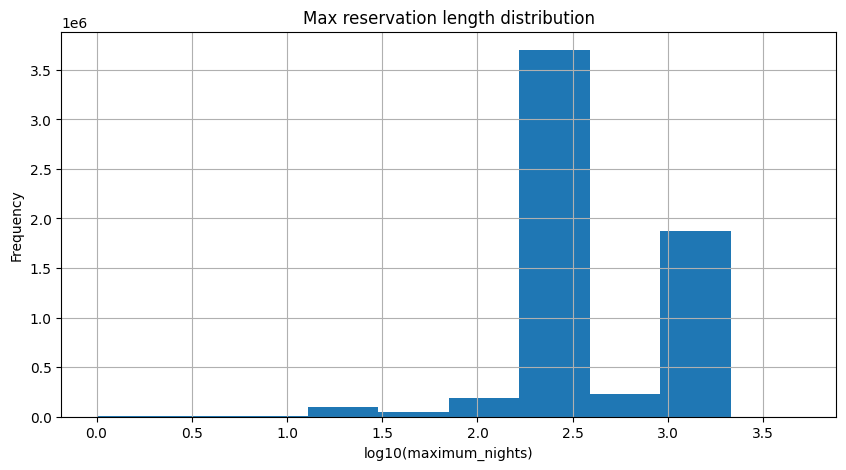

In [ ]:
import numpy as np

calendar_df["max_nights_log"] = np.log10(calendar_df["maximum_nights"])
calendar_df['max_nights_log'].hist(bins=10, figsize=(10, 5))
plt.title('Max reservation length distribution')
plt.xlabel('log10(maximum_nights)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
calendar_df["minimum_nights"].describe()

count    6.141298e+06
mean     5.320668e+01
std      6.201879e+01
min      0.000000e+00
25%      2.000000e+00
50%      7.000000e+00
75%      1.000000e+02
max      1.000000e+03
Name: minimum_nights, dtype: float64

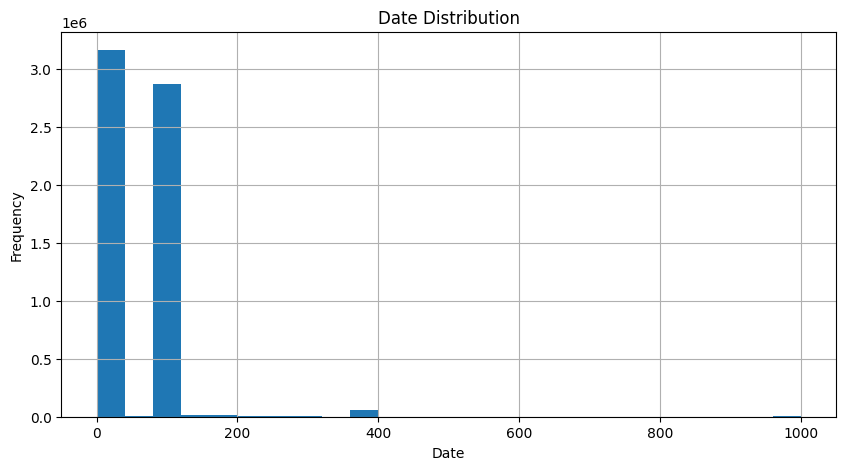

In [ ]:
calendar_df['minimum_nights'].hist(bins=25, figsize=(10, 5))
plt.title('Date Distribution')
plt.xlabel('Date')
plt.ylabel('Frequency')
plt.show()

In [ ]:
calendar_df["minimum_nights"].value_counts()

minimum_nights
100.0    2727828
1.0      1478970
2.0       827347
3.0       486698
101.0     123349
          ...   
151.0          1
181.0          1
97.0           1
92.0           1
273.0          1
Name: count, Length: 100, dtype: int64

### Main takeaways from calendar.csv
- contains data points from exactly a year
- data is probably in Airbnb Open Data format
- only ~23% of the data is fully intact, other rows contain missing values (not counting price columns)
- columns "price" and "adjusted_price" are completely missing
- other columns have 20% NaNs
- minimum_nights, maximum_nights fluctuate depending on the time of year for a reservation

Possible attributes:
- availability_ratio
- minimum_nights column could be used to create a "is long-term stay" feature by grouping locations with minimum stays below and above a certain threshold. An initial threshold could be >= 100 days.